# 04 - Recursive Multi-Step Future Forecasting
## Smart Retail Demand Forecasting & Inventory Planner

**Objective**: Generate a 16-day future demand forecast (`2017-08-16` to `2017-08-31`) for all 33 product families using the trained XGBoost model and true recursive multi-step forecasting.

## 1. Environment Setup & Artifact Loading

In [1]:
import os
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization styles
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["font.size"] = 10

outputs_dir = "../outputs"
models_dir = "../models"
data_dir = "../data"
os.makedirs(outputs_dir, exist_ok=True)

# Load raw datasets
train_raw = pd.read_csv(os.path.join(data_dir, "train.csv"))
test_raw = pd.read_csv(os.path.join(data_dir, "test.csv"))
stores = pd.read_csv(os.path.join(data_dir, "stores.csv"))
oil = pd.read_csv(os.path.join(data_dir, "oil.csv"))
holidays = pd.read_csv(os.path.join(data_dir, "holidays_events.csv"))

# Parse dates
train_raw["date"] = pd.to_datetime(train_raw["date"])
test_raw["date"] = pd.to_datetime(test_raw["date"])
oil["date"] = pd.to_datetime(oil["date"])
holidays["date"] = pd.to_datetime(holidays["date"])

# Load trained XGBoost model
model_path = os.path.join(models_dir, "xgboost_demand_forecaster.json")
model = xgb.XGBRegressor()
model.load_model(model_path)
print(f"Trained XGBoost model loaded from '{model_path}'.")

Trained XGBoost model loaded from '../models\xgboost_demand_forecaster.json'.


## 2. Feature Reconstruction & Preparation for Future Horizon
Preparing known future features (oil price interpolation, holiday indicators, promotion counts, calendar attributes) for `2017-08-16` through `2017-08-31`.

In [2]:
# Historical aggregated sales
history_df = train_raw.groupby(["date", "family"])["sales"].sum().reset_index()
history_df.rename(columns={"sales": "daily_sales"}, inplace=True)

# Process oil price up to 2017-08-31
oil = oil.sort_values("date").set_index("date")
full_oil_range = pd.date_range(start=oil.index.min(), end=pd.to_datetime("2017-08-31"), freq="D")
oil = oil.reindex(full_oil_range)
oil.index.name = "date"
oil["dcoilwtico"] = oil["dcoilwtico"].interpolate(method="linear").bfill().ffill()
oil = oil.reset_index()

# Process holiday indicators up to 2017-08-31
holiday_indicators = holidays.groupby("date").agg(
    is_holiday=("type", lambda x: int(any(t in ["Holiday", "Transfer", "Additional", "Bridge"] for t in x))),
    is_national_holiday=("locale", lambda x: int(any(l == "National" for l in x))),
    is_regional_holiday=("locale", lambda x: int(any(l == "Regional" for l in x))),
    is_local_holiday=("locale", lambda x: int(any(l == "Local" for l in x))),
    is_transferred_holiday=("transferred", lambda x: int(any(x)))
).reset_index()

# Process future promotions from test.csv
test_promo = test_raw.groupby(["date", "family"])["onpromotion"].sum().reset_index()
test_promo.rename(columns={"onpromotion": "promotion_count"}, inplace=True)

# Product family encoding map
family_names = sorted(history_df["family"].unique())
family_map = {name: idx for idx, name in enumerate(family_names)}

feature_cols = ['promotion_count', 'dcoilwtico', 'is_holiday', 'is_national_holiday', 
                'is_regional_holiday', 'is_local_holiday', 'is_transferred_holiday', 
                'day_of_week', 'day_of_month', 'week_of_year', 'month', 'quarter', 
                'year', 'is_weekend', 'is_month_start', 'is_month_end', 
                'lag_1', 'lag_7', 'lag_14', 'lag_28', 
                'rolling_mean_7', 'rolling_mean_14', 'rolling_mean_28', 
                'rolling_std_7', 'rolling_std_28', 'family_code']

print(f"Reconstructed feature environment for {len(family_names)} families.")

Reconstructed feature environment for 33 families.


## 3. Recursive Multi-Step Forecast Execution
Iterating day by day from `2017-08-16` to `2017-08-31`. Dynamic lag and rolling statistics are calculated from the expanding history (actual sales prior to Aug 16 + model predictions after Aug 16).

In [3]:
future_dates = pd.date_range(start="2017-08-16", end="2017-08-31", freq="D")
sales_tracker = history_df.copy()
forecast_records = []
clipped_negative_count = 0

print(f"Executing recursive forecast loop across {len(future_dates)} days...")

for current_date in future_dates:
    # Fetch known future environmental features
    current_oil = oil[oil["date"] == current_date]["dcoilwtico"].values[0]
    
    current_hol = holiday_indicators[holiday_indicators["date"] == current_date]
    if len(current_hol) > 0:
        is_hol = current_hol["is_holiday"].values[0]
        is_nat = current_hol["is_national_holiday"].values[0]
        is_reg = current_hol["is_regional_holiday"].values[0]
        is_loc = current_hol["is_local_holiday"].values[0]
        is_trans = current_hol["is_transferred_holiday"].values[0]
    else:
        is_hol = is_nat = is_reg = is_loc = is_trans = 0

    dow = current_date.dayofweek
    dom = current_date.day
    woy = int(current_date.isocalendar().week)
    m = current_date.month
    q = current_date.quarter
    y = current_date.year
    is_wknd = int(dow >= 5)
    is_m_start = int(current_date.is_month_start)
    is_m_end = int(current_date.is_month_end)

    day_preds = []

    for fam in family_names:
        fam_sales = sales_tracker[sales_tracker["family"] == fam].sort_values("date")["daily_sales"].values
        
        # Calculate dynamic lag features
        l1 = fam_sales[-1]
        l7 = fam_sales[-7]
        l14 = fam_sales[-14]
        l28 = fam_sales[-28]
        
        # Calculate dynamic rolling features
        rm7 = np.mean(fam_sales[-7:])
        rm14 = np.mean(fam_sales[-14:])
        rm28 = np.mean(fam_sales[-28:])
        rstd7 = np.std(fam_sales[-7:], ddof=1) if len(fam_sales) >= 7 else 0.0
        rstd28 = np.std(fam_sales[-28:], ddof=1) if len(fam_sales) >= 28 else 0.0
        
        # Known future promotion count
        promo_match = test_promo[(test_promo["date"] == current_date) & (test_promo["family"] == fam)]
        promo_cnt = promo_match["promotion_count"].values[0] if len(promo_match) > 0 else 0
        
        fam_code = family_map[fam]
        
        row_features = pd.DataFrame([{
            'promotion_count': promo_cnt,
            'dcoilwtico': current_oil,
            'is_holiday': is_hol,
            'is_national_holiday': is_nat,
            'is_regional_holiday': is_reg,
            'is_local_holiday': is_loc,
            'is_transferred_holiday': is_trans,
            'day_of_week': dow,
            'day_of_month': dom,
            'week_of_year': woy,
            'month': m,
            'quarter': q,
            'year': y,
            'is_weekend': is_wknd,
            'is_month_start': is_m_start,
            'is_month_end': is_m_end,
            'lag_1': l1,
            'lag_7': l7,
            'lag_14': l14,
            'lag_28': l28,
            'rolling_mean_7': rm7,
            'rolling_mean_14': rm14,
            'rolling_mean_28': rm28,
            'rolling_std_7': rstd7,
            'rolling_std_28': rstd28,
            'family_code': fam_code
        }])[feature_cols]

        # Predict demand for current date and family
        pred_val = model.predict(row_features)[0]
        if pred_val < 0:
            pred_val = 0.0
            clipped_negative_count += 1
            
        day_preds.append({
            "date": current_date,
            "family": fam,
            "daily_sales": pred_val
        })

    # Append current date predictions to tracker so they serve as lag features for subsequent days
    day_df = pd.DataFrame(day_preds)
    sales_tracker = pd.concat([sales_tracker, day_df], ignore_index=True)
    forecast_records.extend(day_preds)

forecast_df = pd.DataFrame(forecast_records)
forecast_df.rename(columns={"daily_sales": "predicted_sales"}, inplace=True)
print("Recursive forecasting completed successfully!")

Executing recursive forecast loop across 16 days...


Recursive forecasting completed successfully!


## 4. Validation Checks & Output Generation

In [4]:
# Validation Checks
n_dates = forecast_df["date"].nunique()
n_families = forecast_df["family"].nunique()
n_rows = len(forecast_df)
n_nulls = forecast_df["predicted_sales"].isnull().sum()
n_negatives = (forecast_df["predicted_sales"] < 0).sum()
total_demand = forecast_df["predicted_sales"].sum()

print("=== RECURSIVE FORECAST VALIDATION CHECKS ===")
print(f"Dates Count (Expected 16)      : {n_dates} -> {'PASSED' if n_dates == 16 else 'FAILED'}")
print(f"Families Count (Expected 33)   : {n_families} -> {'PASSED' if n_families == 33 else 'FAILED'}")
print(f"Total Rows (Expected 528)      : {n_rows} -> {'PASSED' if n_rows == 528 else 'FAILED'}")
print(f"Null Predictions (Expected 0)   : {n_nulls} -> {'PASSED' if n_nulls == 0 else 'FAILED'}")
print(f"Negative Predictions (Clipped) : {clipped_negative_count} (Clipped to 0.0)")
print(f"Total Forecasted Sales Volume  : {total_demand:,.2f} units")

# Summary Table per Product Family
summary_df = forecast_df.groupby("family").agg(
    total_forecasted_demand_16_days=("predicted_sales", "sum"),
    average_daily_forecast=("predicted_sales", "mean"),
    maximum_daily_forecast=("predicted_sales", "max")
).reset_index().sort_values("total_forecasted_demand_16_days", ascending=False)

display(summary_df.head(10))

# Save Output Datasets
forecast_df.to_csv(os.path.join(outputs_dir, "future_demand_forecast.csv"), index=False)
summary_df.to_csv(os.path.join(outputs_dir, "family_forecast_summary.csv"), index=False)
print(f"Saved 'outputs/future_demand_forecast.csv' and 'outputs/family_forecast_summary.csv'.")

=== RECURSIVE FORECAST VALIDATION CHECKS ===
Dates Count (Expected 16)      : 16 -> PASSED
Families Count (Expected 33)   : 33 -> PASSED
Total Rows (Expected 528)      : 528 -> PASSED
Null Predictions (Expected 0)   : 0 -> PASSED
Negative Predictions (Clipped) : 14 (Clipped to 0.0)
Total Forecasted Sales Volume  : 13,890,275.84 units


,family,total_forecasted_demand_16_days,average_daily_forecast,maximum_daily_forecast
12,GROCERY I,3.813689e+06,238355.552734,305563.187500
3,BEVERAGES,2.885107e+06,180319.198242,241760.578125
30,PRODUCE,1.915558e+06,119722.366211,150506.781250
7,CLEANING,1.020012e+06,63750.726318,84279.296875
8,DAIRY,7.056125e+05,44100.778809,55482.402344
20,LAWN AND GARDEN,6.265700e+05,39160.625977,57287.449219
31,SCHOOL AND OFFICE SUPPLIES,5.139435e+05,32121.465820,47167.781250
5,BREAD/BAKERY,4.541809e+05,28386.305298,38438.765625
24,MEATS,3.080841e+05,19255.258301,28386.447266
28,POULTRY,3.077910e+05,19236.937134,27308.535156


Saved 'outputs/future_demand_forecast.csv' and 'outputs/family_forecast_summary.csv'.


## 5. Visualizations
1. **Total Future Demand Forecast**: Daily aggregated volume across all product families (`2017-08-16` to `2017-08-31`).
2. **Product Family Breakdowns**: Unseen forecasts for `GROCERY I`, `BEVERAGES`, and `CLEANING`.
3. **Historical Continuation**: Combined actual demand curve (`2017-07-01` to `2017-08-15`) and recursive forecast extension (`2017-08-16` to `2017-08-31`).

### 5.1 Total Future Demand Forecast

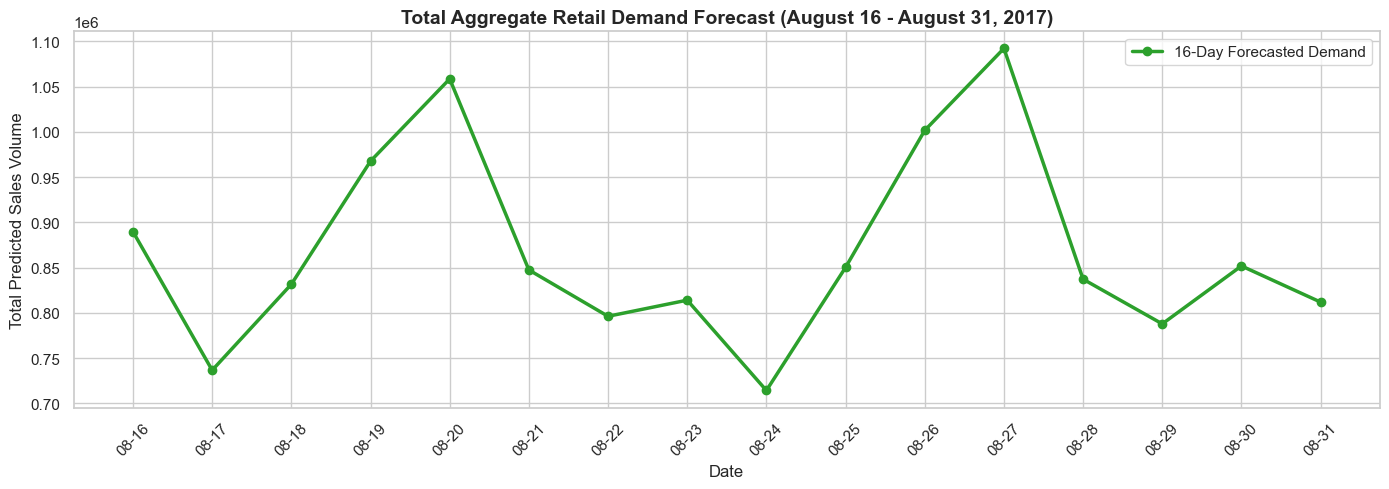

In [5]:
daily_total_forecast = forecast_df.groupby("date")["predicted_sales"].sum().reset_index()

plt.figure(figsize=(14, 5))
plt.plot(daily_total_forecast["date"], daily_total_forecast["predicted_sales"], color="#2ca02c", linewidth=2.5, marker="o", label="16-Day Forecasted Demand")
plt.title("Total Aggregate Retail Demand Forecast (August 16 - August 31, 2017)", fontsize=14, fontweight="bold")
plt.xlabel("Date", fontsize=12)
plt.ylabel("Total Predicted Sales Volume", fontsize=12)
plt.xticks(daily_total_forecast["date"], [d.strftime('%m-%d') for d in daily_total_forecast["date"]], rotation=45)
plt.legend(loc="upper right", frameon=True)
plt.tight_layout()
plt.savefig(os.path.join(outputs_dir, "future_total_demand_forecast.png"), dpi=300)
plt.show()

### 5.2 Product Family Forecast Breakdowns (`GROCERY I`, `BEVERAGES`, `CLEANING`)

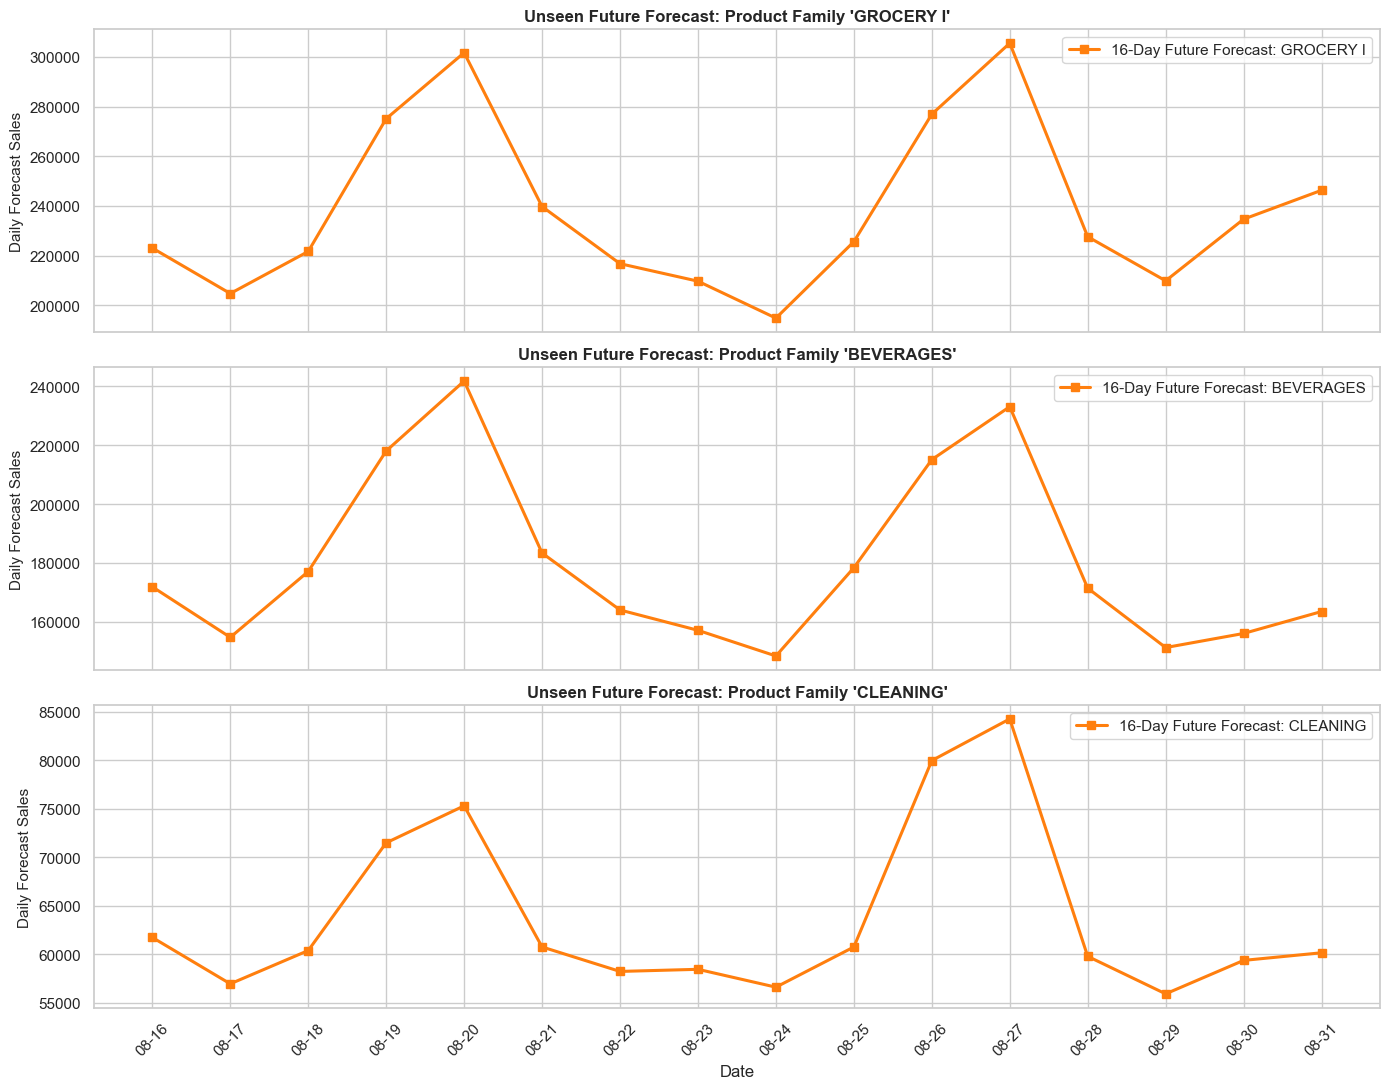

In [6]:
families = ["GROCERY I", "BEVERAGES", "CLEANING"]
fig, axes = plt.subplots(len(families), 1, figsize=(14, 11), sharex=True)

for i, fam in enumerate(families):
    fam_fc = forecast_df[forecast_df["family"] == fam].sort_values("date")
    ax = axes[i]
    ax.plot(fam_fc["date"], fam_fc["predicted_sales"], color="#ff7f0e", linewidth=2.2, marker="s", label=f"16-Day Future Forecast: {fam}")
    ax.set_title(f"Unseen Future Forecast: Product Family '{fam}'", fontsize=12, fontweight="bold")
    ax.set_ylabel("Daily Forecast Sales", fontsize=11)
    ax.legend(loc="upper right", frameon=True)

plt.xlabel("Date", fontsize=12)
plt.xticks(daily_total_forecast["date"], [d.strftime('%m-%d') for d in daily_total_forecast["date"]], rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(outputs_dir, "future_family_forecasts.png"), dpi=300)
plt.show()

### 5.3 Historical Demand + Forecast Continuation

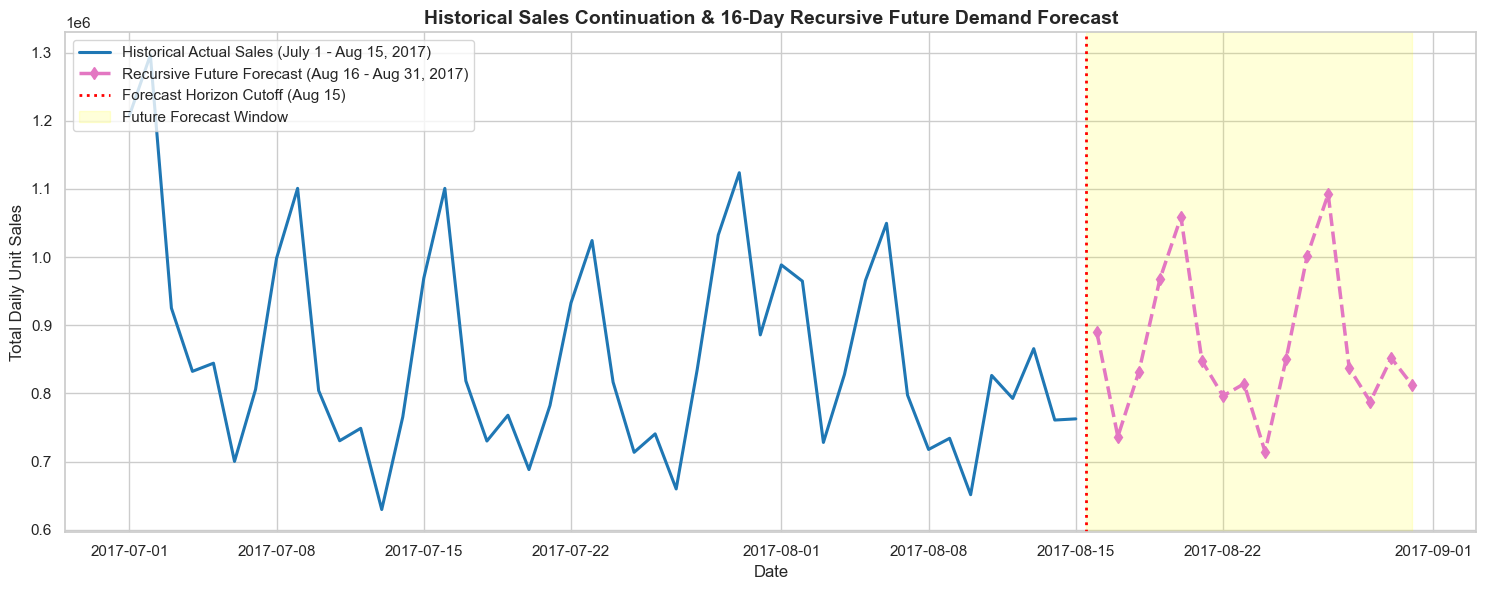

In [7]:
hist_recent = history_df[history_df["date"] >= "2017-07-01"].groupby("date")["daily_sales"].sum().reset_index()

plt.figure(figsize=(15, 6))
plt.plot(hist_recent["date"], hist_recent["daily_sales"], color="#1f77b4", linewidth=2.2, label="Historical Actual Sales (July 1 - Aug 15, 2017)")
plt.plot(daily_total_forecast["date"], daily_total_forecast["predicted_sales"], color="#e377c2", linewidth=2.5, linestyle="--", marker="d", label="Recursive Future Forecast (Aug 16 - Aug 31, 2017)")

plt.axvline(x=pd.to_datetime("2017-08-15 12:00:00"), color="red", linestyle=":", linewidth=2, label="Forecast Horizon Cutoff (Aug 15)")
plt.axvspan(pd.to_datetime("2017-08-15 12:00:00"), pd.to_datetime("2017-08-31"), color="yellow", alpha=0.15, label="Future Forecast Window")

plt.title("Historical Sales Continuation & 16-Day Recursive Future Demand Forecast", fontsize=14, fontweight="bold")
plt.xlabel("Date", fontsize=12)
plt.ylabel("Total Daily Unit Sales", fontsize=12)
plt.legend(loc="upper left", frameon=True)
plt.tight_layout()
plt.savefig(os.path.join(outputs_dir, "historical_and_forecast_continuation.png"), dpi=300)
plt.show()

## Recursive Forecasting Method

### What is Recursive Multi-Step Forecasting?
In real-world demand planning, actual sales for future dates (e.g. August 16 to August 31, 2017) are **completely unknown** at the time the forecast is made.

Because machine learning models rely on historical sales features (such as `lag_1`, `lag_7`, and `rolling_mean_7`), forecasting multiple days into the future presents a challenge: **on August 17th, the prior day's actual sales (`lag_1` from August 16th) does not exist in our historical database.**

To solve this cleanly without data leakage, we use **Recursive Multi-Step Forecasting**:

1. **Day 1 (`2017-08-16`)**: We predict demand using actual historical sales up to `2017-08-15`.
2. **Feedback Loop**: The predicted demand for `2017-08-16` is appended to our sales history series as if it were the actual sale.
3. **Day 2 (`2017-08-17`)**: When constructing features for August 17th, `lag_1` pulls the model's own August 16th prediction, while `lag_2` pulls the August 15th actual sale.
4. **Iterative Progression**: This step-by-step prediction loop continues through `2017-08-31`.

### Benefits of This Approach
- **Zero Future-Data Leakage**: The model strictly uses only information that would be known on each forecasting day in a live production deployment.
- **End-to-End Autoregressive Pipeline**: Allows a single trained model to generate forecasts across arbitrary multi-day planning horizons.